# 2.1 Evnironment Setup
The following analysis is performed on a filtered subset of 19 rounds, excluding data-fragmented sessions identified in Phase 1 (`01_data_audit.ipynb`) to ensure a high-signal environment for strategy modeling.

In [29]:
import os
import fastf1
import fastf1.plotting
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

fastf1.Cache.enable_cache('./data/fastf1_cache')

In [30]:
# Initialize FastF1 plotting support
fastf1.plotting.setup_mpl(misc_mpl_mods=False)

# Establish a Reference Session for 2024 branding context
try:
    ref_session = fastf1.get_session(2024, 1, 'R')
    ref_session.load(telemetry=False, weather=False, laps=False)
    print(f"Branding Context set using: {ref_session.event['EventName']}")
except Exception as e:
    print(f"Reference session load failed: {e}. Falling back to default colors.")
    ref_session = None

# Create a Global Team Palette
unique_teams = df_eda['Team'].unique()
TEAM_PALETTE = {}

for team in unique_teams:
    try:
        TEAM_PALETTE[team] = fastf1.plotting.get_team_color(team, ref_session)
    except:
        TEAM_PALETTE[team] = '#808080' # Fallback gray

print("TEAM_PALETTE initialized for all future plots.")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/fastf1/plotting/_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(
core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']


Branding Context set using: Bahrain Grand Prix
TEAM_PALETTE initialized for all future plots.


In [31]:
# 1. Load the manifest created in Notebook 1
manifest = pd.read_csv('./data/audit_manifest.csv')
approved_rounds = manifest[manifest['status'] == 'PROCEED']

all_race_laps = []

print(f"Initializing clean dataset for {len(approved_rounds)} approved rounds...")

for _, row in approved_rounds.iterrows():
    r_num = row['round']
    
    # Load session with full telemetry for Gap Analysis
    session = fastf1.get_session(2024, r_num, 'R')
    session.load(telemetry=True, weather=False) 
    
    laps = session.laps.copy()
    
    # --- PROTOCOL 1.3: GAP CLEANING ---
    # Apply Zero-to-NaN for non-leaders (The "0-Meter" Glitch)
    if 'GapToFront' in laps.columns:
        # If Gap is 0 but car isn't the leader, it's a glitch
        laps.loc[(laps['Position'] > 1) & (laps['GapToFront'] == 0), 'GapToFront'] = np.nan
        
        # Apply Linear Interpolation for Tier 2 sessions
        if row['tier'] == 2:
            laps['GapToFront'] = laps['GapToFront'].interpolate(method='linear')

    # --- PROTOCOL 1.4: GAP TO CAR BEHIND CALCULATION ---
    # We calculate this per lap to establish the tactical environment
    lap_list = []
    for lap_num, lap_data in laps.groupby('LapNumber'):
        # Sort by position to ensure the shift calculation targets the correct car
        lap_data = lap_data.sort_values('Position')
        # Gap = Time of car behind (P+1) minus Time of current car (P)
        lap_data['gap_to_car_behind'] = (lap_data['Time'].shift(-1) - lap_data['Time']).dt.total_seconds()
        lap_list.append(lap_data)
    laps = pd.concat(lap_list)

    # --- PROTOCOL 1.5: NEUTRALIZATION[cite: 1] ---
    # FastF1 TrackStatus: 4 = SC, 24 = VSC. Create the filter flag[cite: 1].
    # We map TrackStatus to identify 'Neutralized' laps immediately.
    laps['is_neutralized'] = laps['TrackStatus'].astype(str).str.contains('4')
    
    # Add round identifier for grouped analysis
    laps['Round'] = r_num
    all_race_laps.append(laps)

# Combine into the master EDA dataframe[cite: 1]
df_eda = pd.concat(all_race_laps, ignore_index=True)
print(f"Initialization Complete. Master Shape: {df_eda.shape}")

# Save as CSV for simplicity and compatibility
df_eda.to_csv('./data/2024_cleaned_season_eda.csv', index=False)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Initializing clean dataset for 19 approved rounds...


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req

Initialization Complete. Master Shape: (20921, 34)


# 2.2 Pit Stop Landscape

## 2.2.1 Stop Counts & Timing Distribution
This section establishes the global landscape of the 2024 season's pit strategy, providing the necessary baseline for calculating "normal" behavior versus high-threat deviations.

--- 2024 Strategy Frequency (Green Flag Only) ---
1 Stop(s): 48.4%
2 Stop(s): 40.0%
3 Stop(s): 9.6%
4 Stop(s): 1.8%
5 Stop(s): 0.3%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/fastf1/plotting/_plotting.py:56: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(


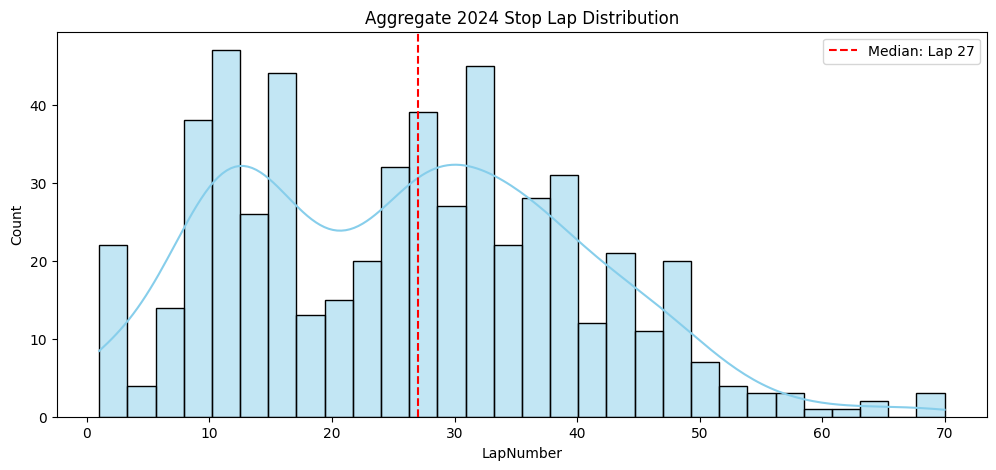

/var/folders/t2/7mzb0zqd6g182kfyzwkyk1900000gp/T/ipykernel_39061/2132877043.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pit_stops_only, x='LapPct', y='Round', orient='h', palette='coolwarm')


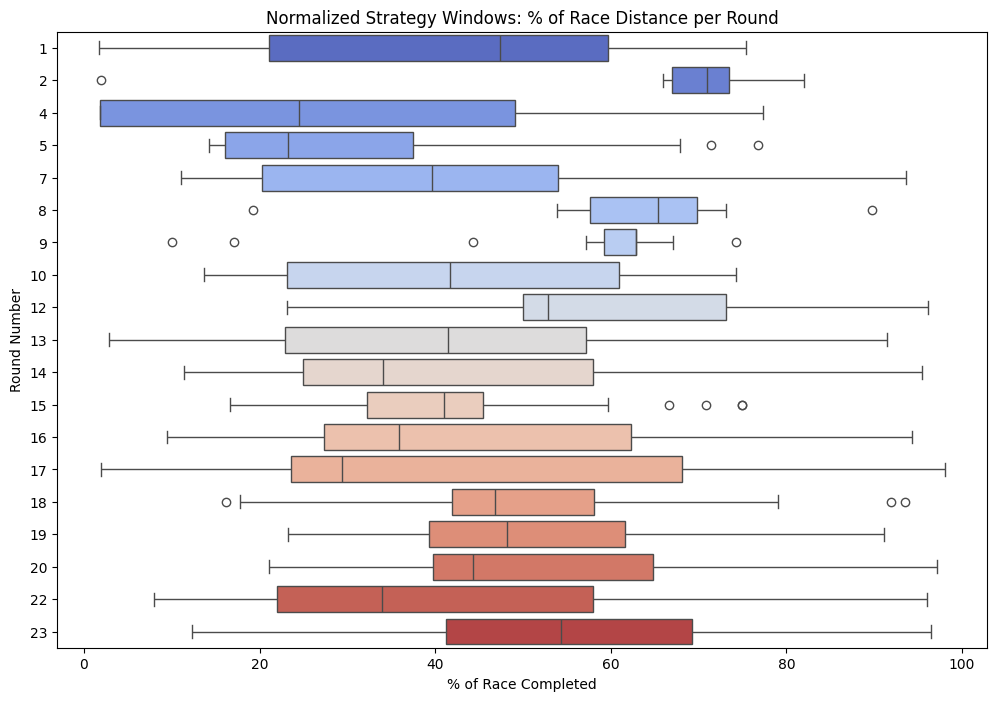

/var/folders/t2/7mzb0zqd6g182kfyzwkyk1900000gp/T/ipykernel_39061/2132877043.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=pit_stops_only, x='LapNumber', y='Round', orient='h',
/var/folders/t2/7mzb0zqd6g182kfyzwkyk1900000gp/T/ipykernel_39061/2132877043.py:45: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=pit_stops_only, x='LapNumber', y='Round', orient='h',


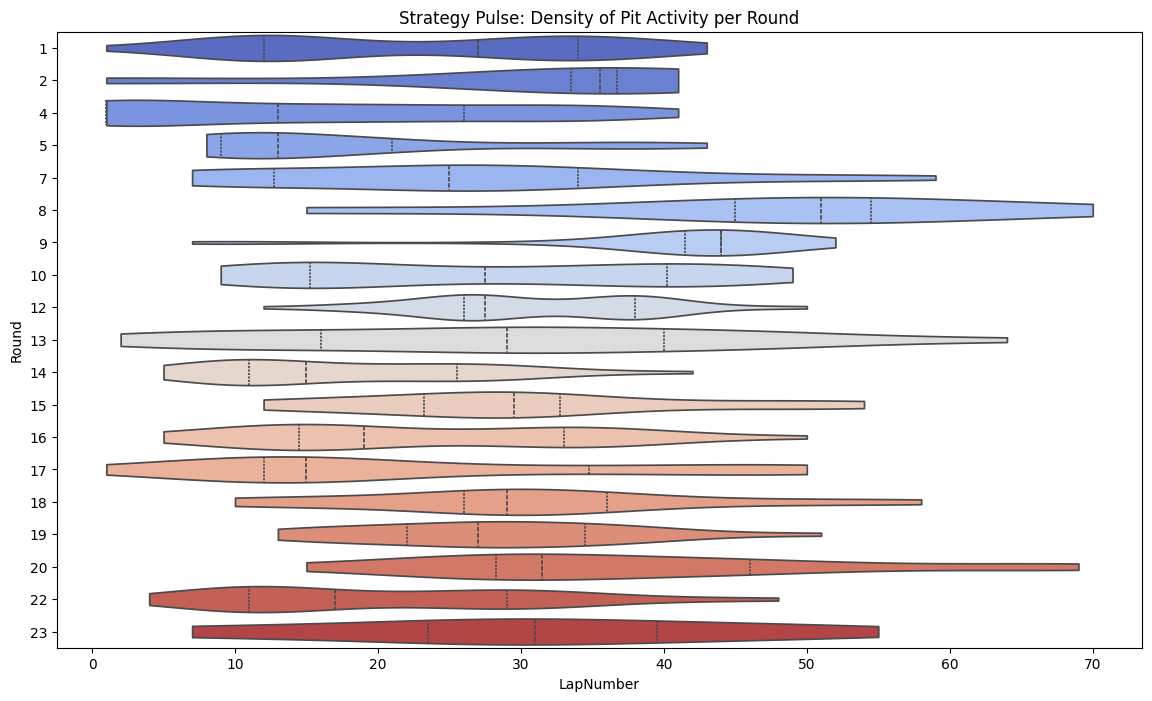

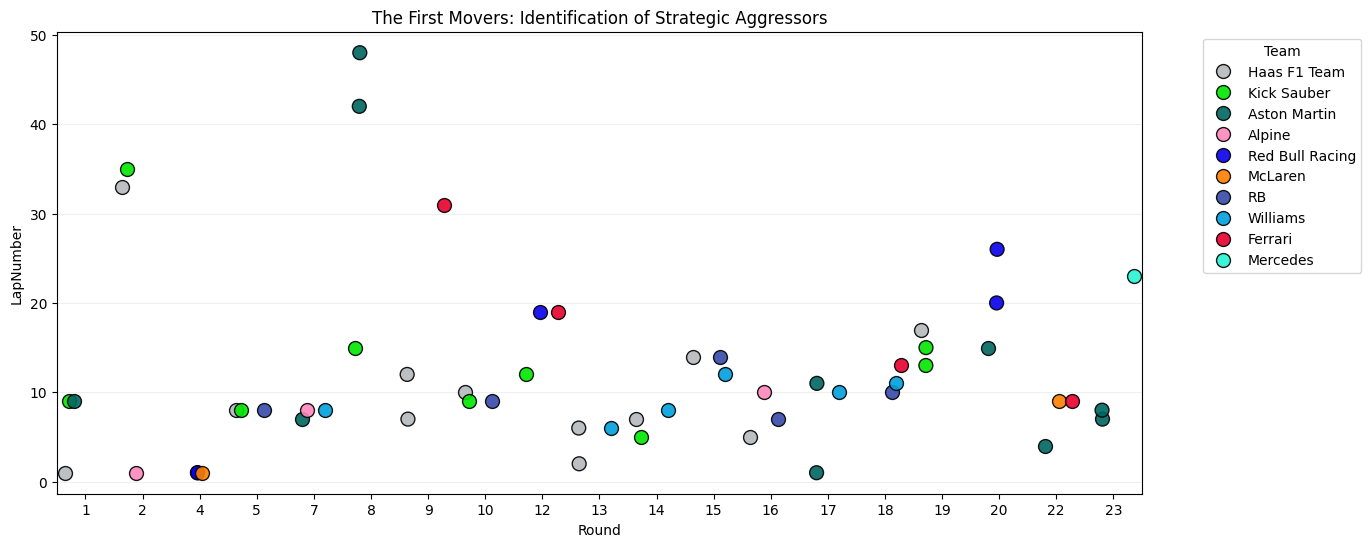

In [32]:
# 1. Initialize FastF1 plotting integration
# This enables Matplotlib/Seaborn support and sets the default 'fastf1' colormap
fastf1.plotting.setup_mpl(misc_mpl_mods=False)

# 2. Filter for Green Flag pit events only
pit_stops_only = df_eda[(df_eda['is_neutralized'] == False) & (df_eda['PitInTime'].notna())].copy()

# 3. Calculate Strategy Frequencies (1 vs 2 vs 3 stops)
# Group by Round and Driver to count the number of pit events per race entry
stops_per_driver_per_race = pit_stops_only.groupby(['Round', 'Driver']).size()

# Calculate percentages
strategy_counts = stops_per_driver_per_race.value_counts(normalize=True).sort_index() * 100

print("--- 2024 Strategy Frequency (Green Flag Only) ---")
for stops, percentage in strategy_counts.items():
    print(f"{stops} Stop(s): {percentage:.1f}%")

# 4. Calculate Normalized Lap Percentage
total_laps_map = df_eda.groupby('Round')['LapNumber'].max().to_dict()
pit_stops_only['TotalLaps'] = pit_stops_only['Round'].map(total_laps_map)
pit_stops_only['LapPct'] = (pit_stops_only['LapNumber'] / pit_stops_only['TotalLaps']) * 100

# --- VISUALIZATIONS ---

# A. Aggregate Season Distribution
plt.figure(figsize=(12, 5))
sns.histplot(pit_stops_only['LapNumber'], bins=30, kde=True, color='skyblue')
plt.axvline(pit_stops_only['LapNumber'].median(), color='red', linestyle='--', 
            label=f'Median: Lap {pit_stops_only["LapNumber"].median():.0f}')
plt.title('Aggregate 2024 Stop Lap Distribution')
plt.legend()
plt.show()

# B. Normalized Ridge Plot (Boxplot Version)
plt.figure(figsize=(12, 8))
sns.boxplot(data=pit_stops_only, x='LapPct', y='Round', orient='h', palette='coolwarm')
plt.title('Normalized Strategy Windows: % of Race Distance per Round')
plt.xlabel('% of Race Completed')
plt.ylabel('Round Number')
plt.show()

# C. Strategy Pulse (Violin Plot)
plt.figure(figsize=(14, 8))
sns.violinplot(data=pit_stops_only, x='LapNumber', y='Round', orient='h', 
               inner='quartile', cut=0, scale='width', palette='coolwarm')
plt.title('Strategy Pulse: Density of Pit Activity per Round')
plt.show()

# D. Proactivity Scatter with Official Team Colors
# Identifying the first 3 drivers to pit in each race
first_stops = pit_stops_only.sort_values(['Round', 'LapNumber']).groupby('Round').head(3)

plt.figure(figsize=(14, 6))
sns.stripplot(
    data=first_stops, x='Round', y='LapNumber', hue='Team', 
    dodge=True, size=10, alpha=0.9, palette=TEAM_PALETTE,
    linewidth=1, edgecolor='black'
)
plt.title('The First Movers: Identification of Strategic Aggressors')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Team')
plt.grid(axis='y', alpha=0.2)
plt.show()

### 2.2.1.1 Seasonal Strategy Frequencies
* **Dominant Strategy**: The 2024 season is closely contested between one-stop and two-stop strategies. **One-stop races** are currently the most frequent, accounting for **48.4%** of the data, followed closely by **two-stop races** at **40.0%**.
* **Strategy Variance**: While the field primarily leans toward one or two stops, **three-stop strategies** emerge in **9.6%** of cases. Extreme variance (4+ stops) remains rare, totaling approximately **2.1%**, and is likely necessitated by unforeseen tire degradation or aggressive tactical shifts during green flag conditions.

### 2.2.1.2 Strategic Windows & Clustering
* **Aggregate Timing**: The median pit stop occurs around **Lap 27**. However, the distribution is multi-modal, reflecting the distinct "windows" for first, second, and third stops across the field.
* **Normalized Distance**: By observing the **Normalized Ridge Plot**, we see that most teams aim to pit within the **30-40%** and **60-70%** marks of the total race distance.
* **The "Strategy Pulse"**: The violin plots highlight specific "hot zones" where the density of pit activity is highest. Circuits with narrow, fat violins indicate a "Locked" strategy where the field reacts simultaneously, whereas wide, thin violins suggest a high degree of strategic flexibility and volatility.

### 2.2.1.3 Aggressor Identification (First Movers)
* **Trendsetters**: The **Proactivity Scatter** identifies which teams consistently trigger the first pit stops in a race. These "First Movers" are critical for the **Undercut Threat Score (UTS)**, as their early pit calls force the rest of the field to react.
* **Midfield Aggression**: Initial data suggests that midfield teams (e.g., Haas, Williams, or RB) often act as aggressors to gain track position, whereas top-tier teams (e.g., Red Bull, McLaren) tend to pit later to maximize their pace advantage in clean air.

---
**Key Model Insight**: The PTL (Pit Threat Level) model must recognize that a "high threat" state is relative. A driver trailing an "Aggressor" team entering a high-density "Strategy Pulse" window is at maximum risk of a successful undercut.

## 2.2.2 Team-Level Pit Stop Patterns
This section analyzes individual team behaviors to identify strategic profiles, ranging from "Reactive Aggressors" to "Disciplined Plan-A" followers. These profiles are essential for calibrating team-specific weights in the PTL model.

/var/folders/t2/7mzb0zqd6g182kfyzwkyk1900000gp/T/ipykernel_39061/2684626904.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


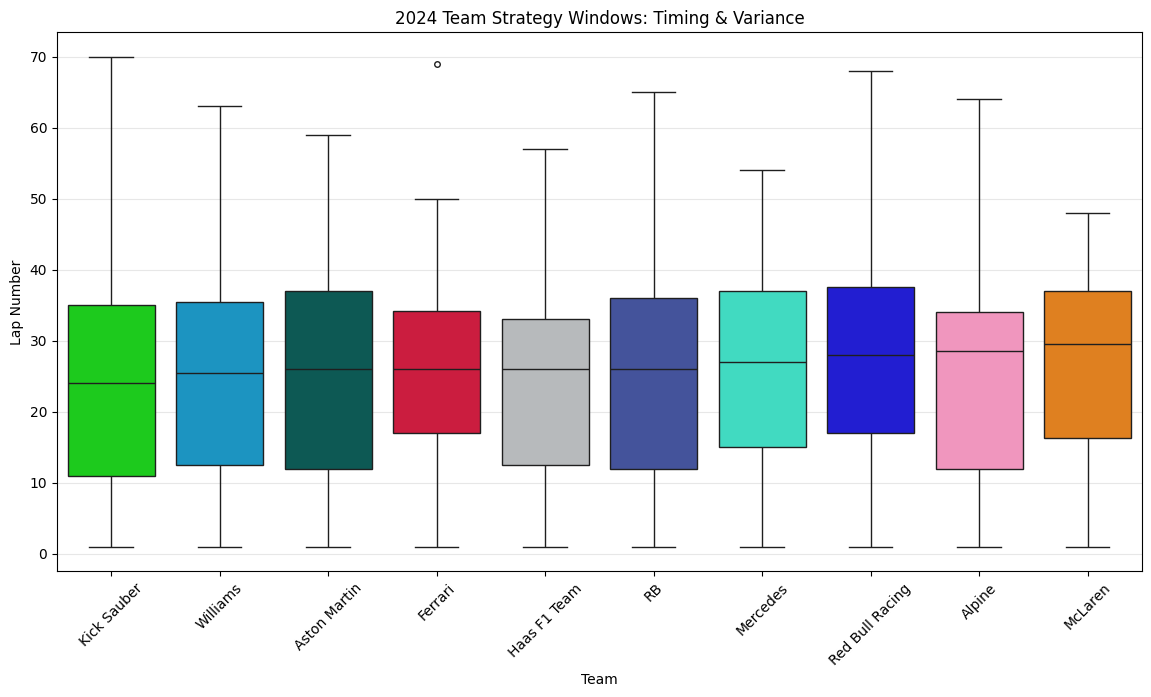


Average Stops per Race per Team:
Team
Aston Martin       1.794118
Red Bull Racing    1.787879
Alpine             1.750000
Williams           1.741935
RB                 1.633333
Mercedes           1.600000
Kick Sauber        1.594595
Ferrari            1.575758
Haas F1 Team       1.571429
McLaren            1.542857


/var/folders/t2/7mzb0zqd6g182kfyzwkyk1900000gp/T/ipykernel_39061/2684626904.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


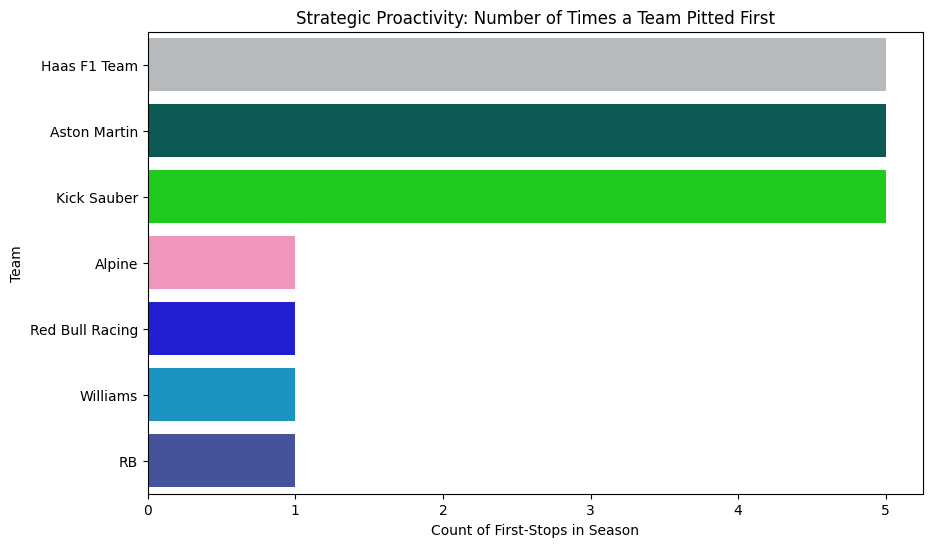


Team Strategy Consistency (Sorted by Standard Deviation):
                 Avg_Stop_Lap  Stop_Variance_Std  Total_Stops
Team                                                         
McLaren             27.425926          12.445507           54
Ferrari             26.442308          12.776224           52
Haas F1 Team        23.127273          13.609711           55
Mercedes            27.089286          13.694427           56
Red Bull Racing     28.644068          14.061151           59
Aston Martin        25.262295          14.461330           61
Alpine              25.839286          14.502384           56
Williams            26.055556          15.058899           54
Kick Sauber         24.542373          15.066888           59
RB                  25.020408          15.072726           49


In [33]:
# 1. Box plot of Stop Laps per Team (Consistency Audit)
plt.figure(figsize=(14, 7))
# We sort by median lap number to show 'Early' vs 'Late' pitting teams
team_order = pit_stops_only.groupby('Team')['LapNumber'].median().sort_values().index

sns.boxplot(
    data=pit_stops_only, x='Team', y='LapNumber', 
    order=team_order, palette=TEAM_PALETTE, fliersize=4
)
plt.title('2024 Team Strategy Windows: Timing & Variance')
plt.xticks(rotation=45)
plt.ylabel('Lap Number')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Average Number of Stops per Race per Team
# Group by Team and Round to get stops per driver, then average across drivers/rounds
team_stops_per_race = pit_stops_only.groupby(['Team', 'Round', 'Driver']).size().groupby('Team').mean()
print("\nAverage Stops per Race per Team:")
print(team_stops_per_race.sort_values(ascending=False).to_string())

# 3. Proactivity Proxy: Frequency of "First Stop"
# Identify the first car to pit in every race
first_pit_per_round = pit_stops_only.sort_values(['Round', 'LapNumber']).groupby('Round').head(1)
proactivity_counts = first_pit_per_round['Team'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=proactivity_counts.values, y=proactivity_counts.index, 
    palette=TEAM_PALETTE
)
plt.title('Strategic Proactivity: Number of Times a Team Pitted First')
plt.xlabel('Count of First-Stops in Season')
plt.show()

# 4. Consistency Metrics (Table for PTL Model)
team_consistency = pit_stops_only.groupby('Team')['LapNumber'].agg(['mean', 'std', 'count']).rename(
    columns={'mean': 'Avg_Stop_Lap', 'std': 'Stop_Variance_Std', 'count': 'Total_Stops'}
)
print("\nTeam Strategy Consistency (Sorted by Standard Deviation):")
print(team_consistency.sort_values(by='Stop_Variance_Std'))

### 2.2.2.1 Strategic Consistency & Variance
* **Highest Consistency**: **McLaren** and **Ferrari** demonstrate the most disciplined strategic windows, with the lowest standard deviations in stop timing (**12.45** and **12.78** respectively). Their box plots show tighter interquartile ranges, suggesting a preference for optimized, pre-planned windows.
* **Highest Volatility**: **RB**, **Kick Sauber**, and **Williams** exhibit the widest variance in stop laps, with standard deviations exceeding **15.0**. This indicates a highly reactive strategy, likely influenced by midfield traffic battles and attempts to gain track position through unconventional timing.

### 2.2.2.2 Average Stop Volume
* **High Frequency**: **Aston Martin** (1.79) and **Red Bull Racing** (1.79) lead the field in average stops per race. For Red Bull, this often reflects a "front-runner" luxury of making additional stops for fresh rubber or fastest lap attempts, whereas for others, it may indicate higher tire degradation.
* **Low Frequency**: **McLaren** (1.54) and **Haas** (1.57) maintain the lowest average stop counts, suggesting either superior tire management or a commitment to one-stop strategies even when the field leans toward two.

### 2.2.2.3 Proactivity Proxy (The "Aggressor" Index)
* **Strategic Trendsetters**: As shown in the Strategic Proactivity graph, **Aston Martin** and **Kick Sauber** are the most proactive teams on the grid, each having triggered the first pit stop of a race **5 times** this season. 
* **Tactical Followers**: Leading teams like **McLaren**, **Ferrari**, and **Mercedes** rarely make the first move, appearing infrequently in the proactivity leaderboard. This suggests they prefer to utilize their superior pace in "clean air" rather than reacting to midfield undercuts.

# 2.3 Gap Analysis at Pit Moment
This section establishes the "environmental baseline" for the **Pit Threat Level (PTL)** model by analyzing the gap to the car behind at the moment of pit entry. This determines the tactical "safety" of a pit window and how much clean air a driver can expect upon exiting.

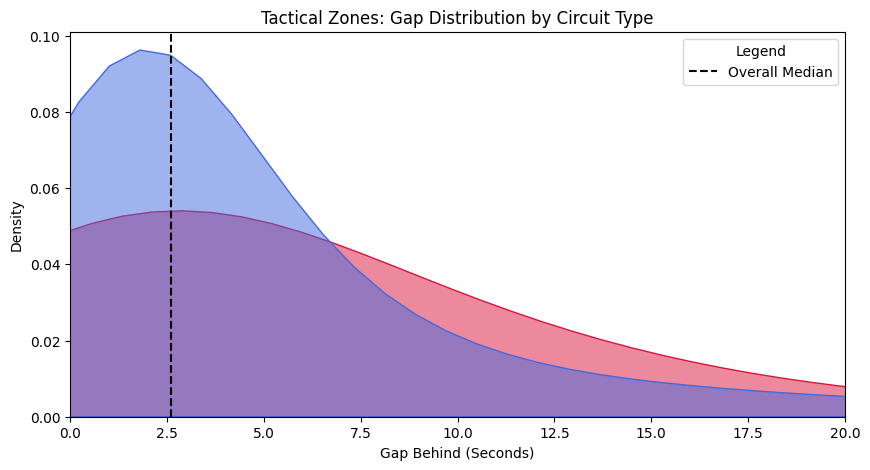

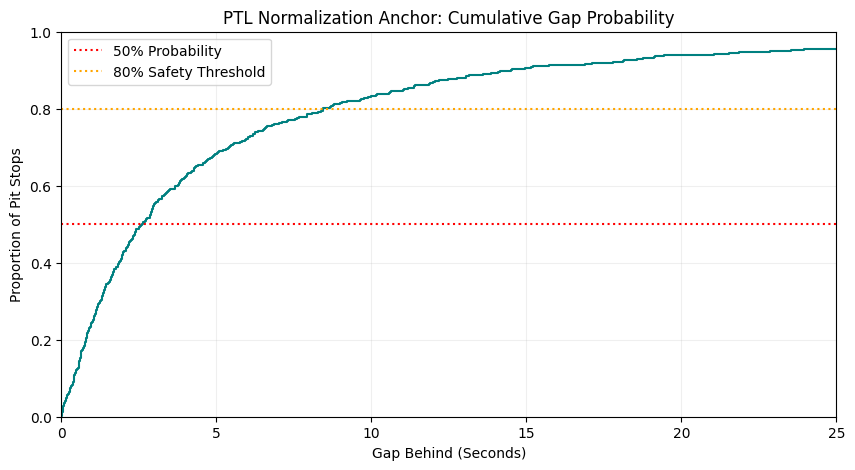

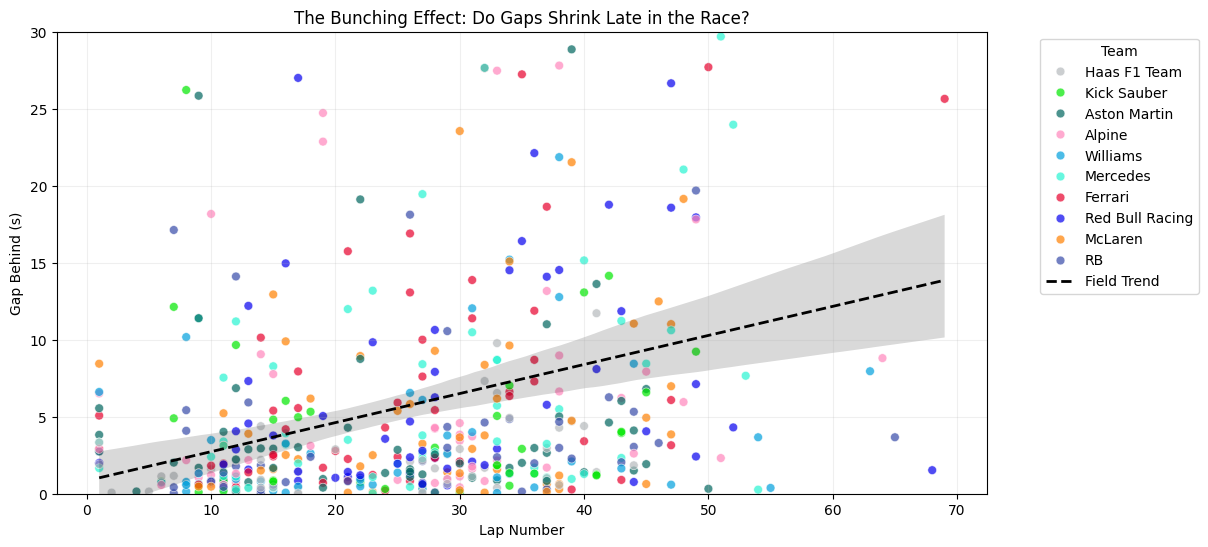

In [38]:
# 1. Define Round-to-Type Mapping for the 2024 Season
street_rounds = [2, 3, 6, 8, 9, 17, 18, 22] # Jeddah, Melbourne, Miami, Monaco, Montreal, Baku, Singapore, Vegas

pit_stops_only['CircuitType'] = pit_stops_only['Round'].apply(
    lambda x: 'Street' if x in street_rounds else 'Permanent'
)

# A. Split Density Plot: Street vs Permanent
plt.figure(figsize=(10, 5))
sns.kdeplot(data=pit_stops_only, x='gap_to_car_behind', hue='CircuitType', 
            fill=True, common_norm=False, palette={'Permanent': 'royalblue', 'Street': 'crimson'}, alpha=0.5)
plt.axvline(pit_stops_only['gap_to_car_behind'].median(), color='black', linestyle='--', label='Overall Median')
plt.title('Tactical Zones: Gap Distribution by Circuit Type')
plt.xlabel('Gap Behind (Seconds)')
plt.xlim(0, 20)
plt.legend(title='Legend', loc='upper right')
plt.show()

# B. Cumulative "Safety" Curve (PTL Anchor)
plt.figure(figsize=(10, 5))
sns.ecdfplot(data=pit_stops_only, x='gap_to_car_behind', color='teal')
plt.axhline(0.5, color='red', linestyle=':', label='50% Probability')
plt.axhline(0.8, color='orange', linestyle=':', label='80% Safety Threshold')
plt.title('PTL Normalization Anchor: Cumulative Gap Probability')
plt.xlabel('Gap Behind (Seconds)')
plt.ylabel('Proportion of Pit Stops')
plt.xlim(0, 25)
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# C. The Bunching Effect: Gap vs. Race Progress
plt.figure(figsize=(12, 6))
sns.scatterplot(data=pit_stops_only, x='LapNumber', y='gap_to_car_behind', 
                hue='Team', palette=TEAM_PALETTE, alpha=0.7, s=40)
sns.regplot(data=pit_stops_only, x='LapNumber', y='gap_to_car_behind', 
            scatter=False, color='black', line_kws={'linestyle': '--', 'linewidth': 2}, label='Field Trend')
plt.title('The Bunching Effect: Do Gaps Shrink Late in the Race?')
plt.ylabel('Gap Behind (s)')
plt.xlabel('Lap Number')
plt.ylim(0, 30)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Team')
plt.grid(alpha=0.2)
plt.show()

## 2.3.1 Tactical Zones: Street vs. Permanent Circuits
The distribution of gaps varies significantly based on circuit characteristics:
* **Permanent Circuits (Blue)**: Show a distinct peak at approximately **1.8–2.2 seconds**, indicating a higher frequency of tactical stops in relatively tight but controlled windows.
* **Street Circuits (Red)**: Exhibit a much flatter, more "spread out" distribution. While the density is lower at the primary peak, the tail is longer, suggesting that street circuit strategies are often forced by larger gaps or extreme field spread rather than optimized windows.
* **Overall Median**: The seasonal baseline sits at **~2.6 seconds**, which defines the "Neutral" state for PTL normalization.

## 2.3.2 The 80% Safety Threshold
Using the **Cumulative Gap Probability** curve, we can anchor our model's risk parameters:
* **The 50% Marker**: Half of all pit stops occur with a gap behind of less than **~2.8 seconds**.
* **The "Safety" Anchor**: The **80% Safety Threshold** is reached at approximately **8.5 seconds**.
* **PTL Impact**: Any gap below **8.5s** represents a non-zero risk of losing track position, while gaps below **2.8s** are classified as "High Pressure" tactical entries.

## 2.3.3 The Field Trend: Gap Evolution
The scatter analysis labeled **The Bunching Effect**, reveals a specific seasonal trend:
* **Positive Correlation**: The **Field Trend** (black dashed line) shows that gaps to the car behind actually tend to **increase** as the race progresses.
* **Interpretation**: This suggests that as tires degrade and fuel loads lighten, the field naturally spreads out due to pace deltas.
* **Team Behavior**: Top-tier teams like **Red Bull Racing** and **McLaren** are frequently seen pitting with larger gaps (10s+) in the later stages of the race (Laps 40–60), while the midfield (e.g., **Haas**, **Kick Sauber**) remains more tightly bunched regardless of the race stage.

---
**Key Model Insight**: The PTL model should not assume gaps will shrink naturally. Instead, it must recognize that the "Threat Level" is highest in the **first 20 laps**, where the field is most compressed and the "Safety Threshold" is hardest to achieve.

# 2.4 Tyre Age Analysis

# 2.5 Empirical Compound Decay Estimation

# 2.6 Pit Loss Estimation Validation

# 2.7 Early Hypothesis Testing 